<a href="https://colab.research.google.com/github/Giacomoooooooo/Pattern-Mind-Group-Project-308331/blob/main/SNA_Project_G_O_T_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
nodes = pd.read_csv("/content/drive/MyDrive/nodes.csv")
edges = pd.read_csv("/content/drive/MyDrive/edges.csv")

In [ ]:
print(nodes.columns)
print(edges.columns)

Index(['# index', ' name'], dtype='object')
Index(['# source', ' target', ' weight'], dtype='object')


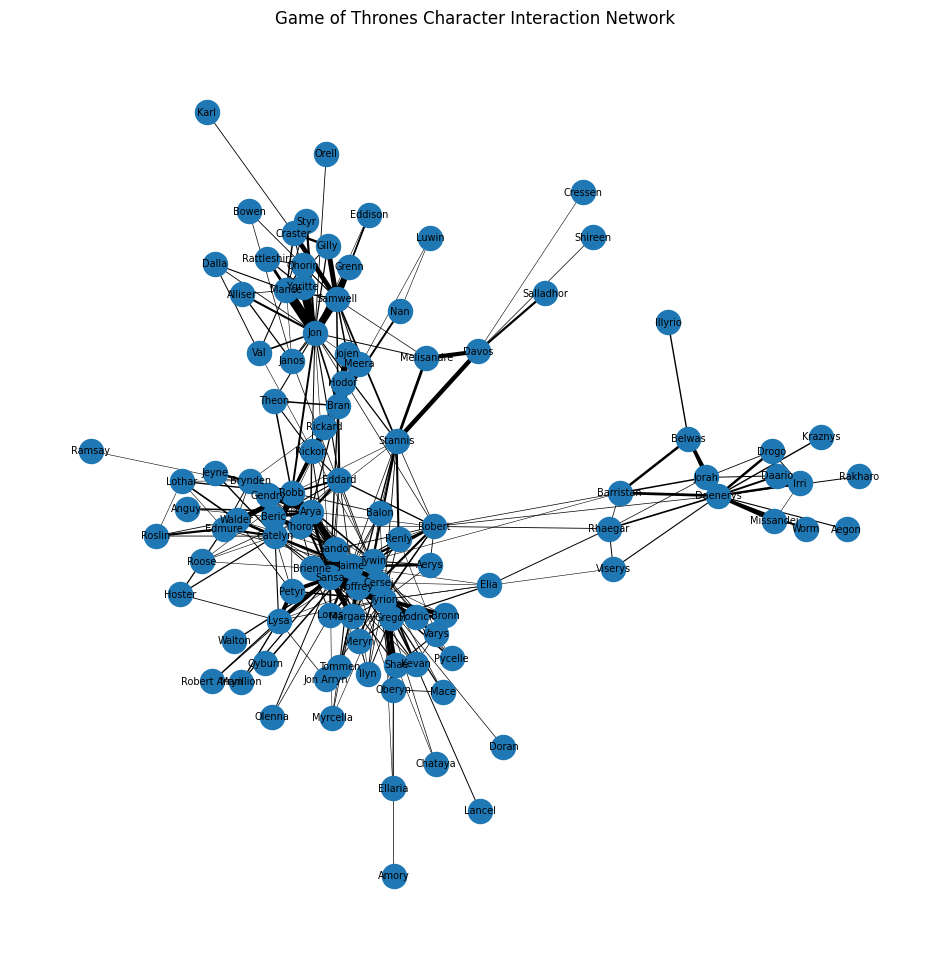

In [ ]:
G = nx.Graph()

# Add nodes (skip invalid ones)
for _, row in nodes.iloc[1:].iterrows():

    node_id = row['# index']
    name = row[' name']

    # Skip node 0 or empty names
    if node_id == 0 or str(name).strip() == "":
        continue

    G.add_node(node_id, label=name)


# Add edges (only if both nodes exist in G)
for _, row in edges.iterrows():

    source = row['# source']
    target = row[' target']
    weight = row[' weight']

    # Only add edge if both nodes are valid
    if source in G.nodes() and target in G.nodes():
        G.add_edge(source, target, weight=weight)


# Plot the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.3)

nx.draw_networkx_nodes(G, pos, node_size=300)

weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=[w * 0.1 for w in weights])

labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels, font_size=7)

plt.title("Game of Thrones Character Interaction Network")
plt.axis("off")
plt.show()





In [ ]:
# Number of nodes
num_nodes = len(nodes.iloc[1:])

# Number of edges
num_edges = len(edges)

# Average Degree: 2E / N
avg_degree = (2 * num_edges) / num_nodes

# Density: 2E / (N(N-1))
density = (2 * num_edges) / (num_nodes * (num_nodes - 1))

# Print table
print("\nNetwork Statistics")
print("--------------------------------")
print(f"{'Metric':<20}{'Value'}")
print("--------------------------------")
print(f"{'Nodes':<20}{num_nodes}")
print(f"{'Edges':<20}{num_edges}")
print(f"{'Average Degree':<20}{avg_degree:.4f}")
print(f"{'Density':<20}{density:.6f}")
print("--------------------------------")


Network Statistics
--------------------------------
Metric              Value
--------------------------------
Nodes               106
Edges               352
Average Degree      6.6415
Density             0.063252
--------------------------------


In [ ]:
# Create table storage
table_data = []

for node in G.nodes():

    neighbors = list(G.neighbors(node))
    degree = len(neighbors)

    edges_between = 0

    for i in range(degree):
        for j in range(i + 1, degree):

            n1 = neighbors[i]
            n2 = neighbors[j]

            if G.has_edge(n1, n2):
                edges_between += 1

    table_data.append([node, degree, edges_between])



print(f"{'ID':<10}{'Degree':<10}{'Edges_between_neighbors'}")
print("-"*40)

for row in table_data:
    print(f"{row[0]:<10}{row[1]:<10}{row[2]}")

ID        Degree    Edges_between_neighbors
----------------------------------------
1         3         3
2         14        22
3         4         6
4         24        77
5         17        42
6         36        114
7         22        53
8         3         3
9         12        21
10        1         0
11        7         9
12        19        57
13        2         1
14        6         9
15        14        29
16        8         13
17        20        68
18        4         6
19        12        36
20        18        60
21        25        47
22        6         12
23        4         4
24        13        39
25        5         8
26        6         12
27        9         18
28        4         3
29        6         8
30        1         0
31        4         4
32        4         5
33        2         1
34        5         7
35        2         1
36        4         5
37        7         13
38        4         4
39        5         5
40        5         8
41        8     

In [ ]:
# Add clustering column
for row in table_data:

    degree = row[1]
    edges_between = row[2]

    if degree < 2:
        clustering = 0
    else:
        clustering = (2 * edges_between) / (degree * (degree - 1))

    row.append(clustering)



print(f"{'ID':<10}{'Degree':<10}{'Edges_between_neighbors':<25}{'Clustering'}")
print("-"*60)

for row in table_data:
    print(f"{row[0]:<10}{row[1]:<10}{row[2]:<25}{row[3]:.4f}")

ID        Degree    Edges_between_neighbors  Clustering
------------------------------------------------------------
1         3         3                        1.0000
2         14        22                       0.2418
3         4         6                        1.0000
4         24        77                       0.2790
5         17        42                       0.3088
6         36        114                      0.1810
7         22        53                       0.2294
8         3         3                        1.0000
9         12        21                       0.3182
10        1         0                        0.0000
11        7         9                        0.4286
12        19        57                       0.3333
13        2         1                        1.0000
14        6         9                        0.6000
15        14        29                       0.3187
16        8         13                       0.4643
17        20        68                       0.3579

In [ ]:
def average_clustering(table):

    total = 0
    count = 0

    for row in table:
        total += row[3]   # clustering column
        count += 1

    if count == 0:
        return 0

    return total / count


avg_cluster = average_clustering(table_data)

print("\nAverage Clustering of Network:", round(avg_cluster, 4))


Average Clustering of Network: 0.552


In [ ]:
# Built-in comparson
avg_clustering_builtin = nx.average_clustering(G)
transitivity_builtin = nx.transitivity(G)

print("\n--- Built-in NetworkX Results ---")
print("Average Clustering (NetworkX):", round(avg_clustering_builtin, 4))
print("Transitivity (NetworkX):", round(transitivity_builtin, 4))


--- Built-in NetworkX Results ---
Average Clustering (NetworkX): 0.552
Transitivity (NetworkX): 0.3301


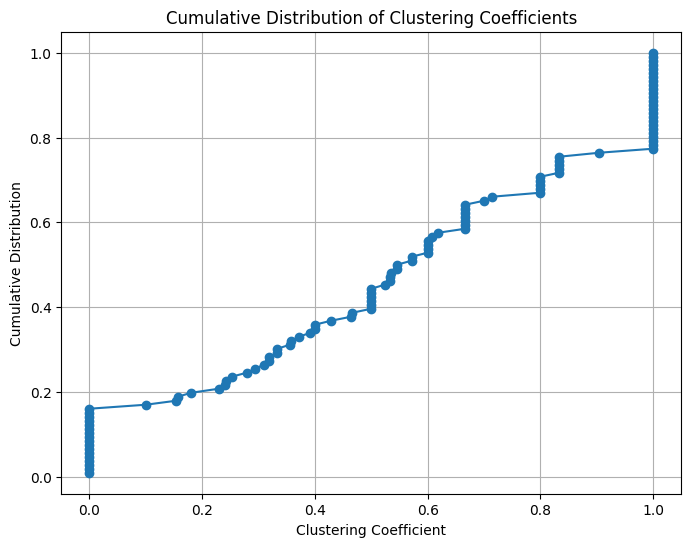

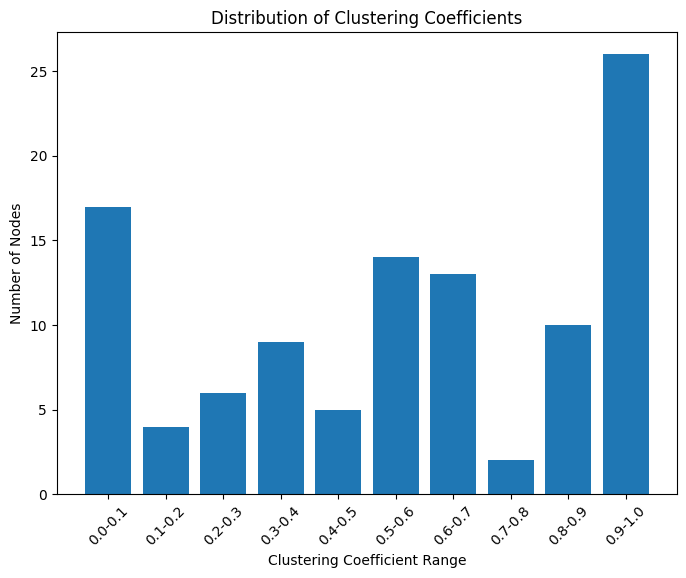

In [ ]:
# ---- Cumulative Distribution + Bar Chart of Clustering ----

# Extract clustering values
clustering_values = []
for row in table_data:
    clustering_values.append(row[3])

# Sort values for CDF
clustering_values.sort()

n = len(clustering_values)

cdf_x = []
cdf_y = []

for i in range(n):
    cdf_x.append(clustering_values[i])
    cdf_y.append((i + 1) / n)

# Plot CDF
plt.figure(figsize=(8,6))
plt.plot(cdf_x, cdf_y, marker='o')

plt.xlabel("Clustering Coefficient")
plt.ylabel("Cumulative Distribution")
plt.title("Cumulative Distribution of Clustering Coefficients")
plt.grid(True)
plt.show()


# Bar Chart (Distribution of Clustering Values)

bins = [0]*10

for value in clustering_values:
    index = int(value * 10)
    if index == 10:
        index = 9
    bins[index] += 1

bin_labels = []
for i in range(10):
    start = i/10
    end = (i+1)/10
    bin_labels.append(f"{start:.1f}-{end:.1f}")

plt.figure(figsize=(8,6))
plt.bar(bin_labels, bins)

plt.xlabel("Clustering Coefficient Range")
plt.ylabel("Number of Nodes")
plt.title("Distribution of Clustering Coefficients")

plt.xticks(rotation=45)
plt.show()

In [ ]:
# Average Neighbor Clustering

clustering_lookup = {}
for row in table_data:
    clustering_lookup[row[0]] = row[3]

for row in table_data:

    node = row[0]
    neighbors = list(G.neighbors(node))

    if len(neighbors) == 0:
        avg_neighbor_cluster = 0
    else:
        total = 0
        count = 0

        for n in neighbors:
            total += clustering_lookup[n]
            count += 1

        avg_neighbor_cluster = total / count

    row.append(avg_neighbor_cluster)




print(f"{'ID':<10}{'Degree':<10}{'Edges_between_neighbors':<25}{'Clustering':<15}{'Avg_neighbor_clustering'}")
print("-"*90)

for row in table_data:
    print(f"{row[0]:<10}{row[1]:<10}{row[2]:<25}{row[3]:<15.4f}{row[4]:.4f}")

ID        Degree    Edges_between_neighbors  Clustering     Avg_neighbor_clustering
------------------------------------------------------------------------------------------
1         3         3                        1.0000         0.4661
2         14        22                       0.2418         0.6547
3         4         6                        1.0000         0.2495
4         24        77                       0.2790         0.4423
5         17        42                       0.3088         0.3921
6         36        114                      0.1810         0.5474
7         22        53                       0.2294         0.5244
8         3         3                        1.0000         0.2916
9         12        21                       0.3182         0.7249
10        1         0                        0.0000         0.4286
11        7         9                        0.4286         0.4783
12        19        57                       0.3333         0.4952
13        2         1

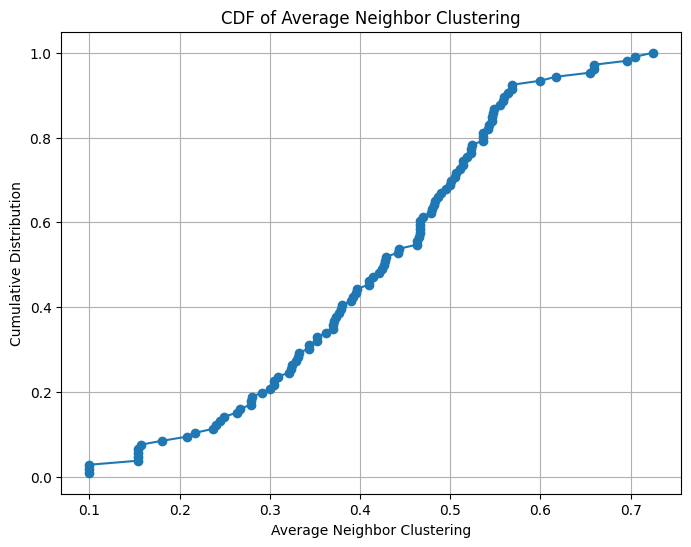

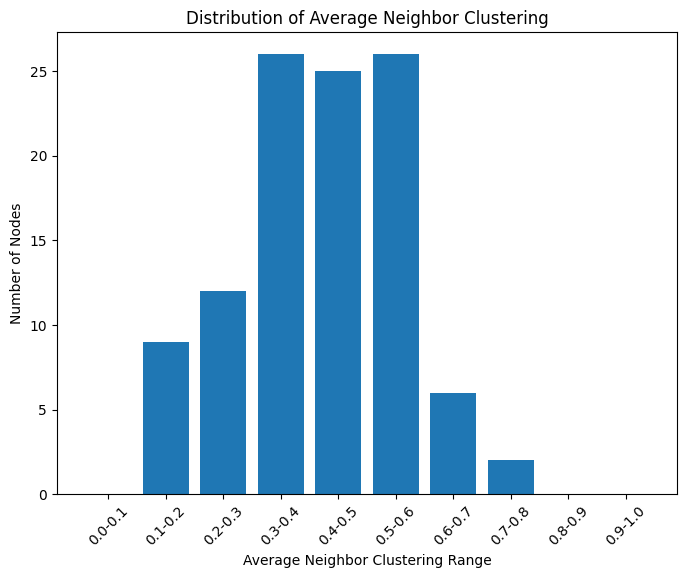

In [ ]:
# Cumulative Distribution of Average Neighbor Clustering

# Extract average neighbor clustering values
avg_neighbor_values = []
for row in table_data:
    avg_neighbor_values.append(row[4])   # new colomsn

# Sort values
avg_neighbor_values.sort()

n = len(avg_neighbor_values)

cdf_x = []
cdf_y = []

for i in range(n):
    cdf_x.append(avg_neighbor_values[i])
    cdf_y.append((i + 1) / n)

# Plot the CDF
plt.figure(figsize=(8,6))
plt.plot(cdf_x, cdf_y, marker='o')

plt.xlabel("Average Neighbor Clustering")
plt.ylabel("Cumulative Distribution")
plt.title("CDF of Average Neighbor Clustering")

plt.grid(True)
plt.show()


# Bar Chart Distribution for visual interpretation

bins = [0]*10

for value in avg_neighbor_values:
    index = int(value * 10)
    if index == 10:
        index = 9
    bins[index] += 1

bin_labels = []
for i in range(10):
    start = i/10
    end = (i+1)/10
    bin_labels.append(f"{start:.1f}-{end:.1f}")

plt.figure(figsize=(8,6))
plt.bar(bin_labels, bins)

plt.xlabel("Average Neighbor Clustering Range")
plt.ylabel("Number of Nodes")
plt.title("Distribution of Average Neighbor Clustering")

plt.xticks(rotation=45)
plt.show()

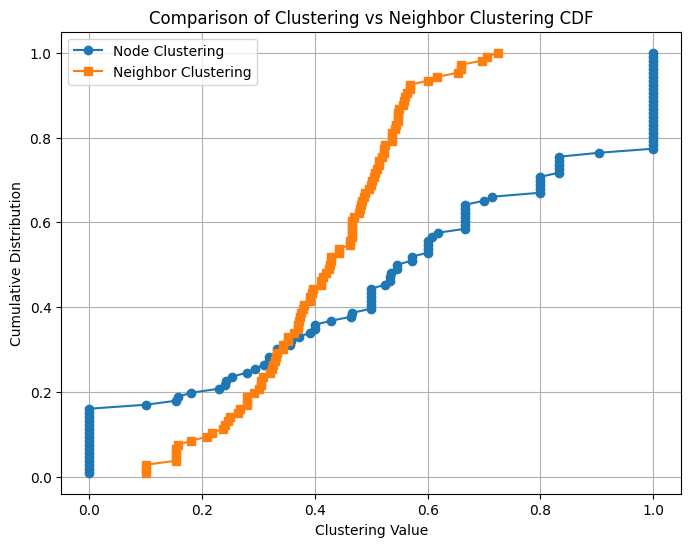

In [ ]:
# Compare Cumulative Distributions

# Extract values
clustering_values = []
neighbor_clustering_values = []

for row in table_data:
    clustering_values.append(row[3])
    neighbor_clustering_values.append(row[4])

# Sort values
clustering_values.sort()
neighbor_clustering_values.sort()

n = len(clustering_values)

# Compute the CDFs
cdf_cluster_x = []
cdf_cluster_y = []

cdf_neighbor_x = []
cdf_neighbor_y = []

for i in range(n):
    cdf_cluster_x.append(clustering_values[i])
    cdf_cluster_y.append((i + 1) / n)

    cdf_neighbor_x.append(neighbor_clustering_values[i])
    cdf_neighbor_y.append((i + 1) / n)

# Plot comparison graph
plt.figure(figsize=(8,6))

plt.plot(cdf_cluster_x, cdf_cluster_y, marker='o', label="Node Clustering")
plt.plot(cdf_neighbor_x, cdf_neighbor_y, marker='s', label="Neighbor Clustering")

plt.xlabel("Clustering Value")
plt.ylabel("Cumulative Distribution")
plt.title("Comparison of Clustering vs Neighbor Clustering CDF")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Centrality Measures

delta = 0.5   # decay factor

# Finding shortest path distances for decay centrality
shortest_paths = dict(nx.all_pairs_shortest_path_length(G))

decay_centrality = {}

for node in G.nodes():

    total = 0

    for target, dist in shortest_paths[node].items():

        if node != target:
            total += delta ** dist

    decay_centrality[node] = total


# Betweenness centrality (built-in)
betweenness = nx.betweenness_centrality(G)

# Closeness centrality (built-in)
closeness = nx.closeness_centrality(G)


# Results

print(f"{'ID':<10}{'Decay':<15}{'Betweenness':<15}{'Closeness'}")
print("-"*55)

for node in G.nodes():
    print(f"{node:<10}{decay_centrality[node]:<15.4f}{betweenness[node]:<15.4f}{closeness[node]:.4f}")

ID        Decay          Betweenness    Closeness
-------------------------------------------------------
1         15.1250        0.0000         0.3281
2         20.7812        0.0312         0.3818
3         20.0000        0.0000         0.3918
4         28.1875        0.1012         0.4795
5         28.2500        0.2054         0.4976
6         31.5000        0.2001         0.5122
7         27.3750        0.0659         0.4688
8         15.9062        0.0000         0.3420
9         18.5938        0.0074         0.3571
10        9.3438         0.0000         0.2618
11        18.1875        0.0198         0.3535
12        28.1250        0.0808         0.4861
13        14.5625        0.0000         0.3292
14        16.0625        0.0006         0.3387
15        24.0312        0.0640         0.4200
16        19.7188        0.0048         0.3763
17        25.6875        0.0269         0.4430
18        15.3125        0.0000         0.3333
19        22.3125        0.0060         0.4038
2

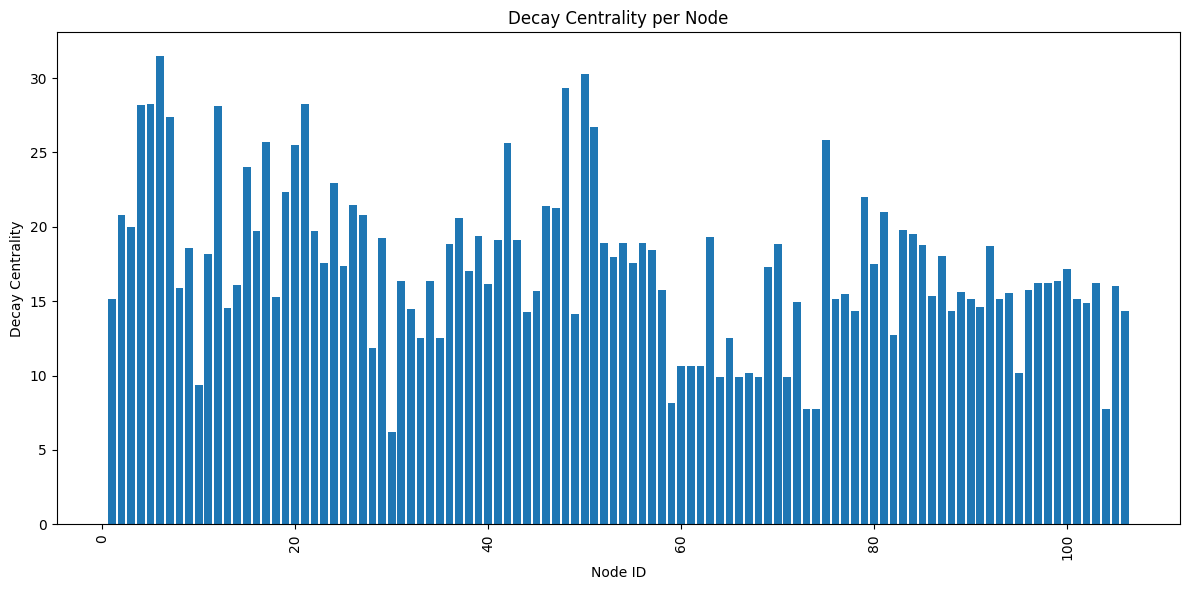

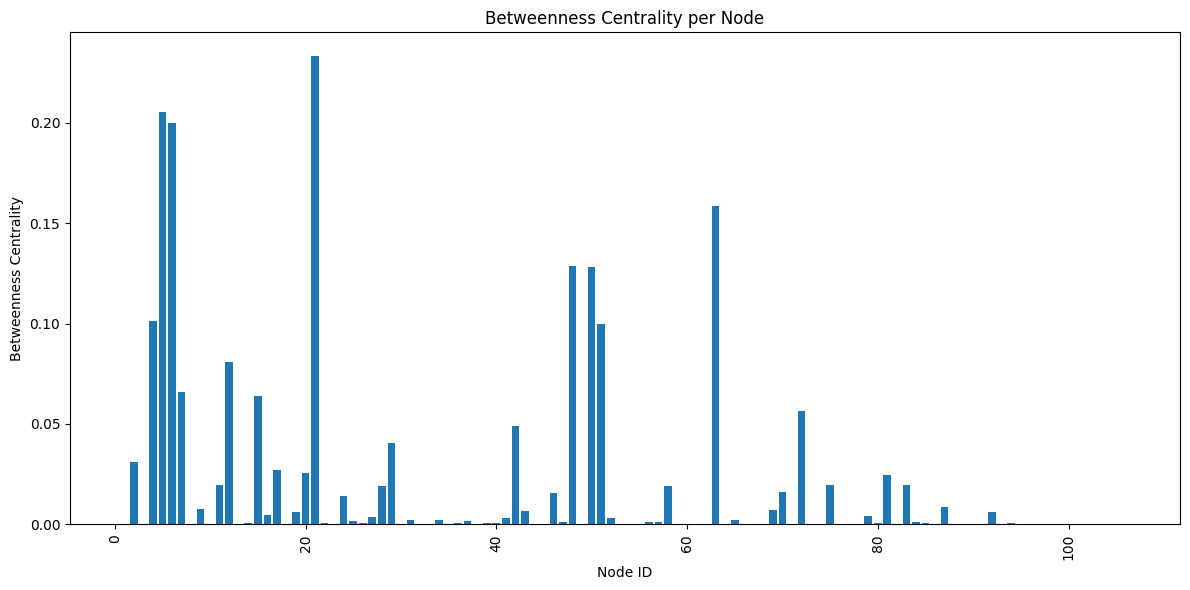

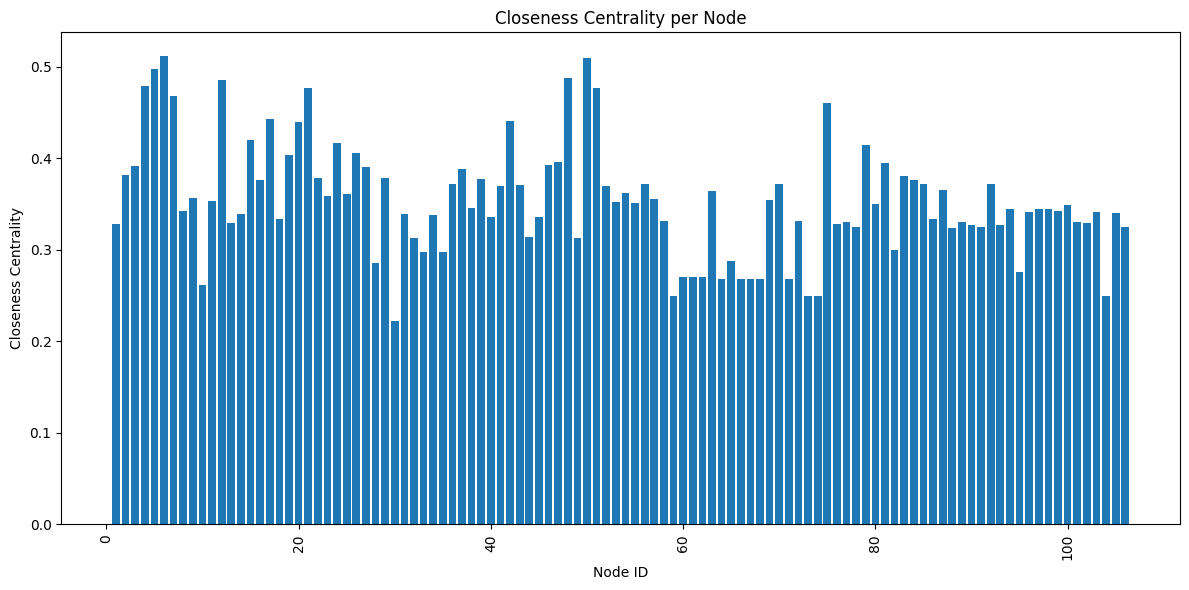

In [ ]:
# Separate Charts for Centrality Measures

nodes = list(G.nodes())

decay_vals = [decay_centrality[n] for n in nodes]
bet_vals = [betweenness[n] for n in nodes]
close_vals = [closeness[n] for n in nodes]

# Decay Centrality Chart
plt.figure(figsize=(12,6))
plt.bar(nodes, decay_vals)
plt.xlabel("Node ID")
plt.ylabel("Decay Centrality")
plt.title("Decay Centrality per Node")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# Betweenness Centrality Chart
plt.figure(figsize=(12,6))
plt.bar(nodes, bet_vals)
plt.xlabel("Node ID")
plt.ylabel("Betweenness Centrality")
plt.title("Betweenness Centrality per Node")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# Closeness Centrality Chart
plt.figure(figsize=(12,6))
plt.bar(nodes, close_vals)
plt.xlabel("Node ID")
plt.ylabel("Closeness Centrality")
plt.title("Closeness Centrality per Node")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Weighted Shell Decomposition (Character Names)
------------------------------------------------
Shell 1: ['Amory', 'Illyrio', 'Karl', 'Aegon', 'Kraznys', 'Rakharo', 'Worm', 'Cressen', 'Salladhor', 'Qyburn', 'Orell', 'Lancel', 'Ramsay', 'Shireen', 'Doran', 'Walton']
Shell 2: ['Anguy', 'Luwin', 'Nan', 'Jeyne', 'Missandei', 'Davos', 'Bowen', 'Styr', 'Jon Arryn', 'Olenna', 'Ellaria', 'Rickard', 'Chataya']
Shell 3: ['Grenn', 'Alliser', 'Belwas', 'Hoster', 'Irri', 'Viserys', 'Eddison', 'Dalla', 'Melisandre', 'Marillion', 'Robert Arryn', 'Mace', 'Daario', 'Drogo', 'Val', 'Jorah', 'Daenerys', 'Barristan', 'Rhaegar']
Shell 4: ['Aerys', 'Oberyn', 'Gendry', 'Roose', 'Theon', 'Bronn', 'Roslin', 'Elia', 'Pycelle', 'Shae', 'Craster', 'Gilly', 'Janos', 'Myrcella', 'Rattleshirt', 'Ygritte', 'Mance', 'Beric', 'Thoros', 'Podrick', 'Lothar', 'Tommen', 'Qhorin']
Shell 5: ['Samwell', 'Rickon', 'Hodor', 'Jojen', 'Edmure', 'Varys', 'Kevan', 'Margaery', 'Brynden', 'Meera', 'Walder']
Shell 6: ['Bran', 'Balon'

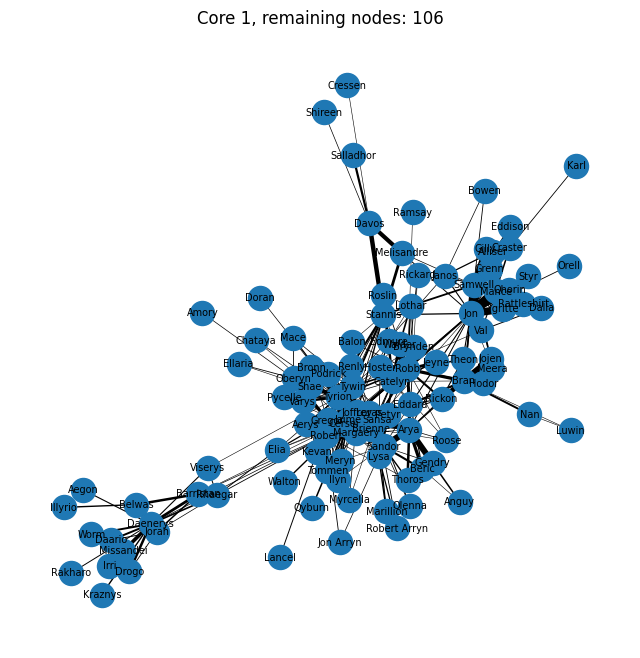

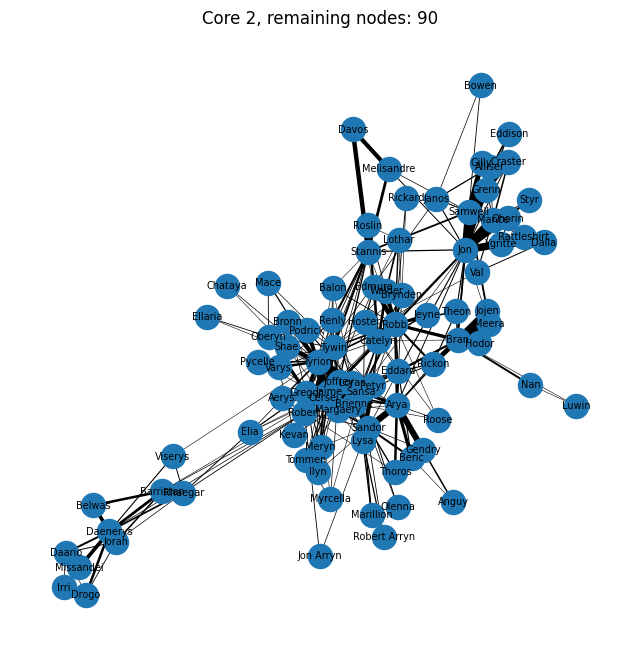

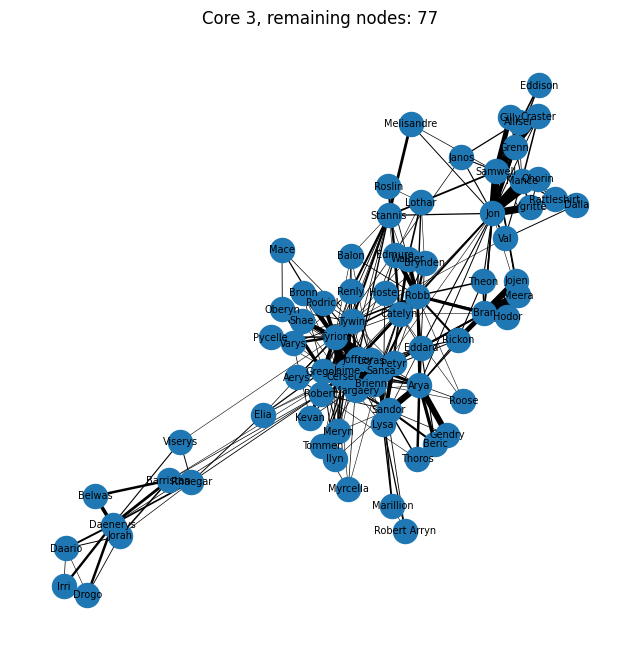

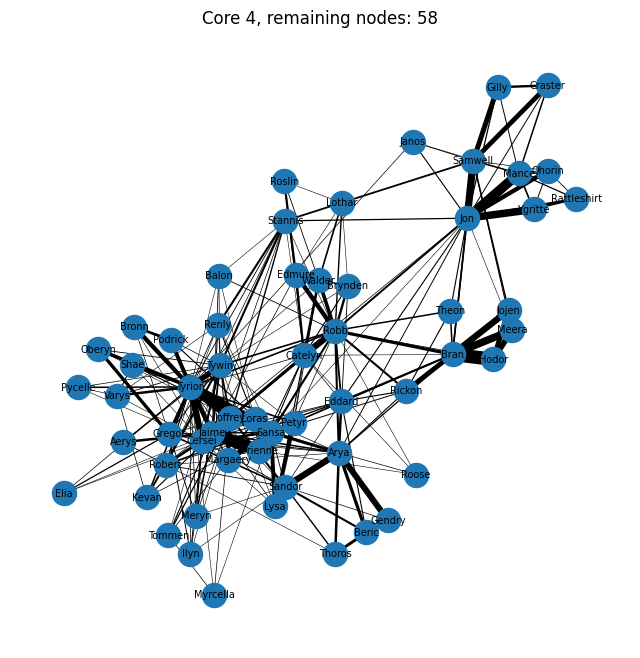

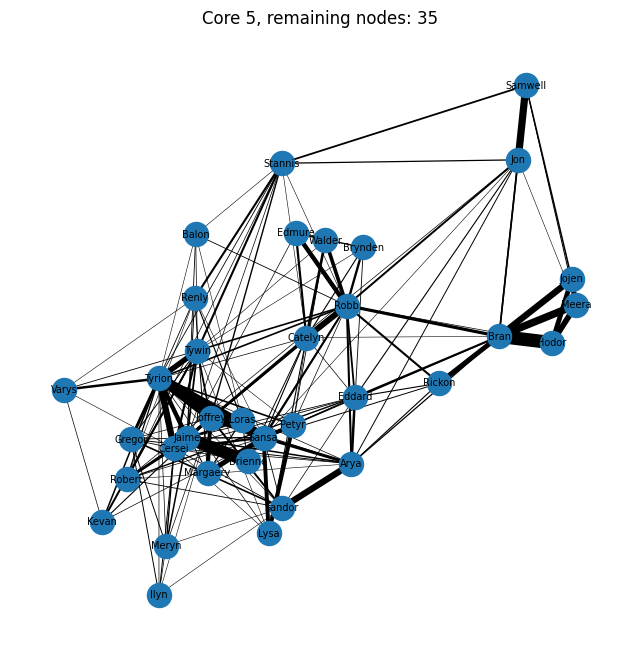

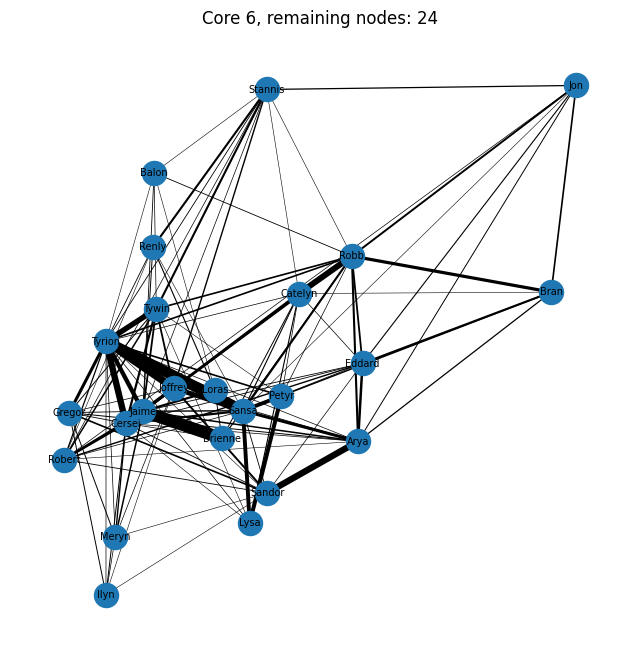

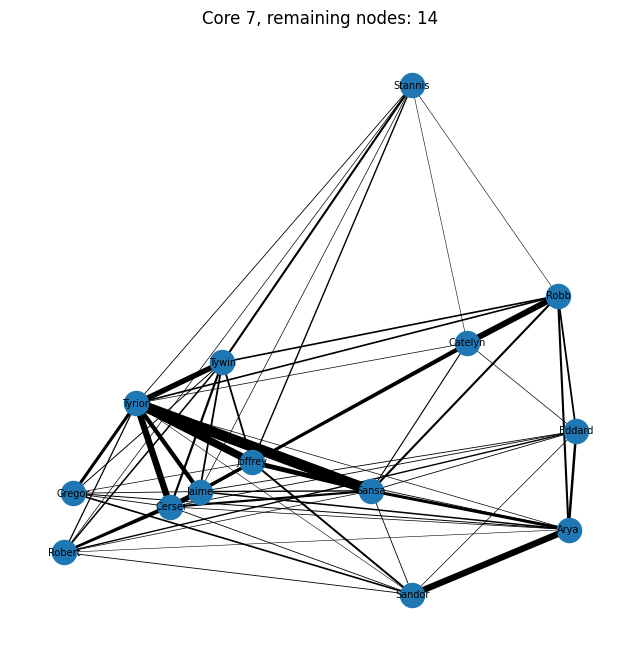

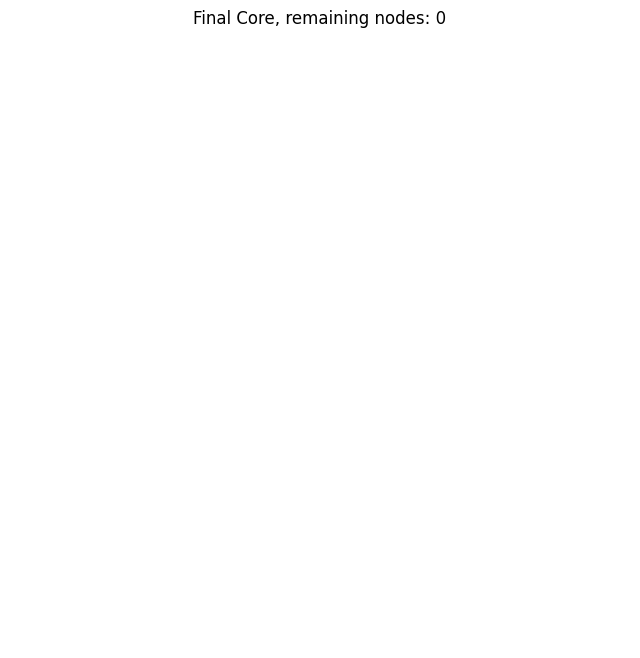

In [ ]:
# ---- Weighted Shell Decomposition + Step-by-Step Visualization ----

import copy
import numpy as np

G_temp = copy.deepcopy(G)
shells = []

# ---- Build ID -> Name mapping ----
id_to_name = {}
for node, data in G.nodes(data=True):
    id_to_name[node] = data.get('label', str(node))

# ---- Compute max weight ----
max_weight = 0
for u, v in G.edges():
    w = G[u][v]['weight']
    if w > max_weight:
        max_weight = w

# ---- Strength function ----
def compute_strength(graph, node):
    strength = 0
    for neighbor in graph.neighbors(node):
        w = graph[node][neighbor]['weight']
        strength += 1 + np.log(1 + w / max_weight)
    return strength

# ---- Start from minimum strength ----
min_strength = float('inf')
for node in G_temp.nodes():
    s = compute_strength(G_temp, node)
    if s < min_strength:
        min_strength = s

core_level = int(min_strength)

# ---- Decomposition ----
while len(G_temp.nodes()) > 0:

    removed_in_level = []

    while True:
        removed_nodes = []

        for node in list(G_temp.nodes()):
            strength = compute_strength(G_temp, node)

            if strength <= core_level:
                removed_nodes.append(node)

        if len(removed_nodes) == 0:
            break

        removed_in_level.extend(removed_nodes)

        for node in removed_nodes:
            G_temp.remove_node(node)

    if len(removed_in_level) > 0:
        shells.append((core_level, removed_in_level))

    core_level += 1


# ---- Print shells (with character names) ----
print("\nWeighted Shell Decomposition (Character Names)")
print("------------------------------------------------")

for i, (level, nodes_in_shell) in enumerate(shells, start=1):
    names = [id_to_name[n] for n in nodes_in_shell]
    print(f"Shell {i}: {names}")


# ---- Step-by-step graph visualization ----

G_step = copy.deepcopy(G)
pos = nx.spring_layout(G, k=0.3)  # fixed layout

for i, (level, nodes_in_shell) in enumerate(shells, start=1):

    plt.figure(figsize=(8,8))

    # Draw graph BEFORE removing shell
    nx.draw_networkx_nodes(G_step, pos, node_size=300)

    weights = [G_step[u][v]['weight'] for u, v in G_step.edges()]
    nx.draw_networkx_edges(G_step, pos, width=[w * 0.1 for w in weights])

    labels = nx.get_node_attributes(G_step, 'label')
    nx.draw_networkx_labels(G_step, pos, labels, font_size=7)

    remaining_nodes = len(G_step.nodes())

    plt.title(f"Core {i}, remaining nodes: {remaining_nodes}")
    plt.axis("off")
    plt.show()

    # Remove shell
    G_step.remove_nodes_from(nodes_in_shell)


# ---- Final core graph ----
plt.figure(figsize=(8,8))

nx.draw_networkx_nodes(G_step, pos, node_size=300)

weights = [G_step[u][v]['weight'] for u, v in G_step.edges()]
nx.draw_networkx_edges(G_step, pos, width=[w * 0.1 for w in weights])

labels = nx.get_node_attributes(G_step, 'label')
nx.draw_networkx_labels(G_step, pos, labels, font_size=7)

plt.title(f"Final Core, remaining nodes: {len(G_step.nodes())}")
plt.axis("off")
plt.show()

Nodes in largest component: 106
Edges in largest component: 347

Girvan-Newman Best Modularity: 0.3519
Number of communities: 4

Greedy Modularity: 0.4489
Number of communities: 6

Best Method: Greedy Modularity Optimization
Final Modularity: 0.4489


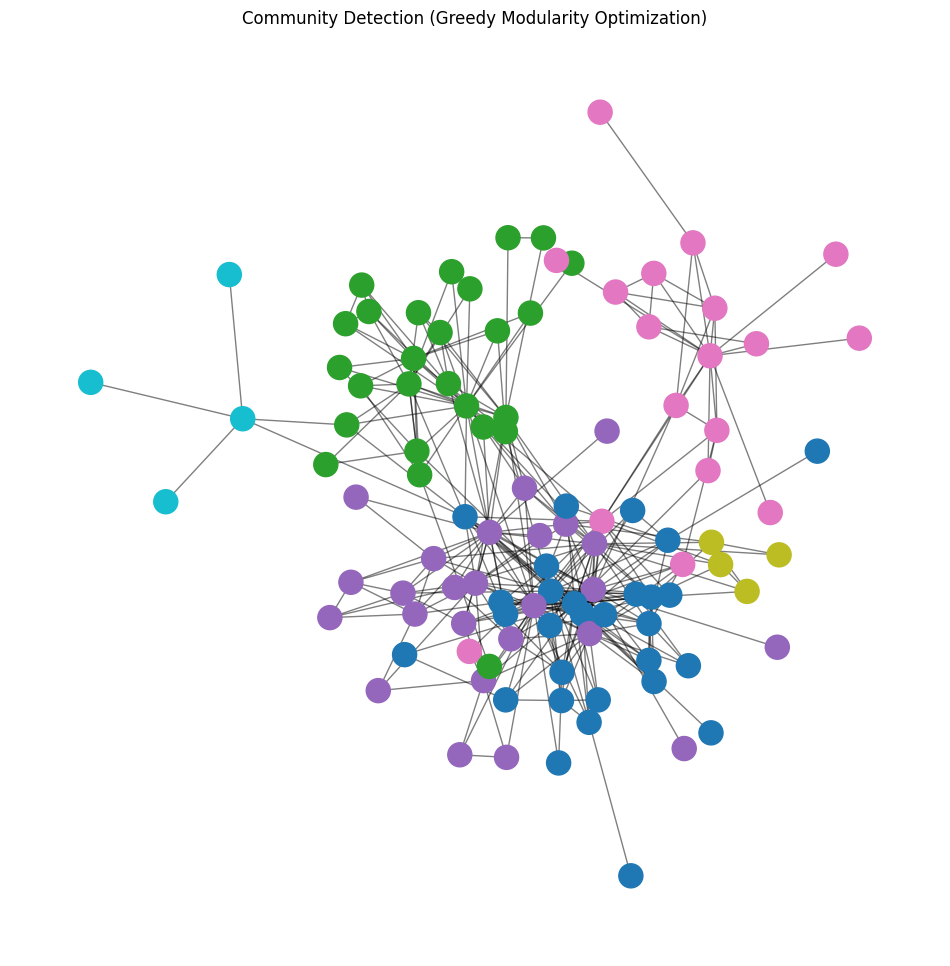

In [ ]:
# ---- Community Detection Preparation ----

# Remove self-loops
G_simple = G.copy()
G_simple.remove_edges_from(nx.selfloop_edges(G_simple))

# Convert to unweighted graph
G_unweighted = nx.Graph()
G_unweighted.add_edges_from(G_simple.edges())

# Keep largest connected component
largest_cc = max(nx.connected_components(G_unweighted), key=len)
G_cc = G_unweighted.subgraph(largest_cc).copy()

print("Nodes in largest component:", len(G_cc.nodes()))
print("Edges in largest component:", len(G_cc.edges()))


# ---- 1. Bridge Removal (Girvan-Newman) ----

from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity

comp_gen = girvan_newman(G_cc)

best_partition = None
best_modularity = -1

# Try first few splits
for i in range(5):
    communities = next(comp_gen)
    communities = [set(c) for c in communities]

    mod = modularity(G_cc, communities)

    if mod > best_modularity:
        best_modularity = mod
        best_partition = communities

print("\nGirvan-Newman Best Modularity:", round(best_modularity, 4))
print("Number of communities:", len(best_partition))


# ---- 2. Modularity Optimization (Greedy) ----

from networkx.algorithms.community import greedy_modularity_communities

greedy_communities = list(greedy_modularity_communities(G_cc))
greedy_mod = modularity(G_cc, greedy_communities)

print("\nGreedy Modularity:", round(greedy_mod, 4))
print("Number of communities:", len(greedy_communities))


# ---- Choose Best Partition ----

if greedy_mod >= best_modularity:
    final_partition = greedy_communities
    method = "Greedy Modularity Optimization"
    final_mod = greedy_mod
else:
    final_partition = best_partition
    method = "Girvan-Newman (Bridge Removal)"
    final_mod = best_modularity

print(f"\nBest Method: {method}")
print(f"Final Modularity: {round(final_mod, 4)}")


# ---- Assign community labels to nodes ----

node_community = {}

for i, community in enumerate(final_partition):
    for node in community:
        node_community[node] = i


# ---- Visualization ----

plt.figure(figsize=(12,12))

pos = nx.spring_layout(G_cc, k=0.3)

colors = [node_community[node] for node in G_cc.nodes()]

nx.draw_networkx_nodes(G_cc, pos, node_size=300, node_color=colors, cmap=plt.cm.tab10)

nx.draw_networkx_edges(G_cc, pos, alpha=0.5)

labels = nx.get_node_attributes(G_cc, 'label')
nx.draw_networkx_labels(G_cc, pos, labels, font_size=7)

plt.title(f"Community Detection ({method})")
plt.axis("off")
plt.show()

In [ ]:
# ---- Prepare graph (undirected, unweighted, no loops, largest CC) ----

G_simple = G.copy()
G_simple.remove_edges_from(nx.selfloop_edges(G_simple))

G_unweighted = nx.Graph()
G_unweighted.add_edges_from(G_simple.edges())

largest_cc = max(nx.connected_components(G_unweighted), key=len)
G_cc = G_unweighted.subgraph(largest_cc).copy()


# ---- Function to compute CN + AA ----

import pandas as pd
import itertools

def link_prediction_scores(G):

    nodes = list(G.nodes())
    data = []

    for u, v in itertools.combinations(nodes, 2):

        # Only consider missing links
        if G.has_edge(u, v):
            continue

        # ---- Common Neighbors (CN) ----
        neighbors_u = set(G.neighbors(u))
        neighbors_v = set(G.neighbors(v))
        cn = len(neighbors_u & neighbors_v)

        # ---- Adamic-Adar (AA) ----
        aa = 0
        for w in neighbors_u & neighbors_v:
            deg = len(list(G.neighbors(w)))
            if deg > 1:
                aa += 1 / np.log(deg)

        data.append([u, v, cn, aa])

    df = pd.DataFrame(data, columns=["node1", "node2", "CN", "AA"])

    # ---- Normalize CN and AA to [0,1] ----
    for col in ["CN", "AA"]:
        min_val = df[col].min()
        max_val = df[col].max()
        if max_val > min_val:
            df[col + "_norm"] = (df[col] - min_val) / (max_val - min_val)
        else:
            df[col + "_norm"] = 0

    # ---- Combined score (mean of normalized values) ----
    df["Combined"] = (df["CN_norm"] + df["AA_norm"]) / 2

    return df


# ---- Run function ----

df_scores = link_prediction_scores(G_cc)


# ---- Get Top 10 predictions ----

top_CN = df_scores.sort_values(by="CN", ascending=False).head(10)
top_AA = df_scores.sort_values(by="AA", ascending=False).head(10)
top_combined = df_scores.sort_values(by="Combined", ascending=False).head(10)


# ---- Map IDs to names ----

id_to_name = {n: G.nodes[n]['label'] for n in G.nodes() if 'label' in G.nodes[n]}

def add_names(df):
    df = df.copy()
    df["name1"] = df["node1"].map(id_to_name)
    df["name2"] = df["node2"].map(id_to_name)
    return df[["name1", "name2", "CN", "AA", "Combined"]]


print("\nTop 10 by Common Neighbors (CN)")
print(add_names(top_CN))

print("\nTop 10 by Adamic-Adar (AA)")
print(add_names(top_AA))

print("\nTop 10 by Combined Score")
print(add_names(top_combined))


Top 10 by Common Neighbors (CN)
        name1    name2  CN        AA  Combined
1681    Tywin    Sansa  10  4.064760  1.000000
2639     Arya  Catelyn   9  3.528715  0.884062
1680    Tywin  Catelyn   9  3.538050  0.885210
1474    Jaime   Sandor   9  3.277104  0.853112
2700   Cersei     Robb   9  3.172060  0.840190
1551   Robert     Robb   8  2.666748  0.728033
1620   Tyrion   Eddard   8  2.694488  0.731445
1679    Tywin     Arya   8  2.820449  0.746939
1228  Stannis    Sansa   8  2.740855  0.737148
1545   Robert  Joffrey   8  2.677330  0.729334

Top 10 by Adamic-Adar (AA)
        name1    name2  CN        AA  Combined
1681    Tywin    Sansa  10  4.064760  1.000000
1680    Tywin  Catelyn   9  3.538050  0.885210
2639     Arya  Catelyn   9  3.528715  0.884062
1474    Jaime   Sandor   9  3.277104  0.853112
2700   Cersei     Robb   9  3.172060  0.840190
1679    Tywin     Arya   8  2.820449  0.746939
1228  Stannis    Sansa   8  2.740855  0.737148
1620   Tyrion   Eddard   8  2.694488  0.731445

Real Graph:
Nodes: 106
Edges: 347
Average Degree: 6.5472

BA Graph:
Nodes: 106
Edges: 309
Average Degree: 5.8302

--- Comparison ---
Metric                   Real Graph     BA Graph
--------------------------------------------------
Average Degree           6.5472         5.8302
Clustering               0.5520         0.1369
Transitivity             0.3301         0.0985
Diameter                 6              5


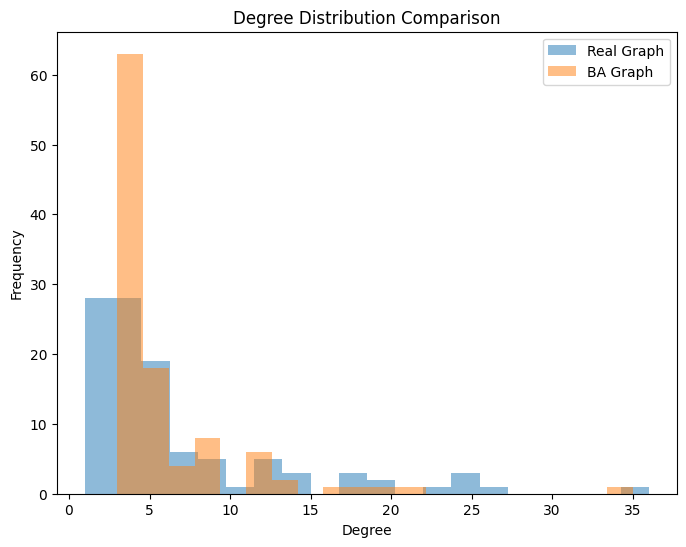

In [ ]:
# ---- Step 1: Get real graph statistics ----

N = len(G_cc.nodes())
E = len(G_cc.edges())

avg_degree_real = (2 * E) / N

print("Real Graph:")
print("Nodes:", N)
print("Edges:", E)
print("Average Degree:", round(avg_degree_real, 4))


# ---- Step 2: Build Preferential Attachment Graph ----

# In BA model: avg_degree ≈ 2m → so m ≈ avg_degree / 2
m = int(avg_degree_real / 2)

G_ba = nx.barabasi_albert_graph(N, m)

print("\nBA Graph:")
print("Nodes:", len(G_ba.nodes()))
print("Edges:", len(G_ba.edges()))
print("Average Degree:", round((2 * len(G_ba.edges())) / len(G_ba.nodes()), 4))


# ---- Step 3: Compare metrics ----

# Average clustering
clustering_real = nx.average_clustering(G_cc)
clustering_ba = nx.average_clustering(G_ba)

# Transitivity
trans_real = nx.transitivity(G_cc)
trans_ba = nx.transitivity(G_ba)

# Diameter (only if connected)
if nx.is_connected(G_ba):
    diam_ba = nx.diameter(G_ba)
else:
    diam_ba = "Not connected"

diam_real = nx.diameter(G_cc)

print("\n--- Comparison ---")
print(f"{'Metric':<25}{'Real Graph':<15}{'BA Graph'}")
print("-"*50)
print(f"{'Average Degree':<25}{avg_degree_real:<15.4f}{(2*len(G_ba.edges())/N):.4f}")
print(f"{'Clustering':<25}{clustering_real:<15.4f}{clustering_ba:.4f}")
print(f"{'Transitivity':<25}{trans_real:<15.4f}{trans_ba:.4f}")
print(f"{'Diameter':<25}{diam_real:<15}{diam_ba}")


# ---- Step 4: Degree Distribution Plot ----

real_degrees = [deg for _, deg in G_cc.degree()]
ba_degrees = [deg for _, deg in G_ba.degree()]

plt.figure(figsize=(8,6))

plt.hist(real_degrees, bins=20, alpha=0.5, label="Real Graph")
plt.hist(ba_degrees, bins=20, alpha=0.5, label="BA Graph")

plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution Comparison")

plt.legend()
plt.show()

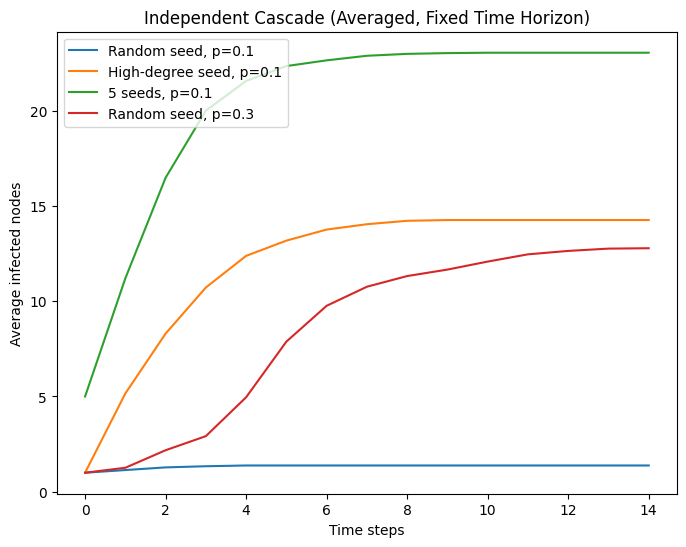

In [ ]:
# ---- Independent Cascade Model (FINAL FIXED VERSION) ----

import random
import numpy as np
import matplotlib.pyplot as plt

# ---- IC function (fixed length) ----
def independent_cascade(G, seeds, p=0.1, max_steps=15):

    active = set(seeds)
    newly_active = set(seeds)

    steps = [len(active)]

    for _ in range(max_steps - 1):

        next_active = set()

        for node in newly_active:
            for neighbor in G.neighbors(node):
                if neighbor not in active:
                    if random.random() < p:
                        next_active.add(neighbor)

        if next_active:
            active.update(next_active)
            newly_active = next_active
        else:
            newly_active = set()

        steps.append(len(active))

    return steps


# ---- Averaging function (forces same length) ----
def average_simulation(G, seeds, p, runs=50, max_steps=15):

    all_runs = []

    for _ in range(runs):
        steps = independent_cascade(G, seeds, p, max_steps=max_steps)
        all_runs.append(steps)

    avg = np.mean(all_runs, axis=0)

    return avg


# ---- Define scenarios ----

seed_random = [random.choice(list(G_cc.nodes()))]
high_deg_node = max(G_cc.degree(), key=lambda x: x[1])[0]
seed_multi = random.sample(list(G_cc.nodes()), 5)

# ---- Run simulations ----

avg1 = average_simulation(G_cc, seed_random, p=0.1)
avg2 = average_simulation(G_cc, [high_deg_node], p=0.1)
avg3 = average_simulation(G_cc, seed_multi, p=0.1)
avg4 = average_simulation(G_cc, seed_random, p=0.3)

# ---- Plot ----

plt.figure(figsize=(8,6))

plt.plot(avg1, label="Random seed, p=0.1")
plt.plot(avg2, label="High-degree seed, p=0.1")
plt.plot(avg3, label="5 seeds, p=0.1")
plt.plot(avg4, label="Random seed, p=0.3")

plt.xlabel("Time steps")
plt.ylabel("Average infected nodes")
plt.title("Independent Cascade (Averaged, Fixed Time Horizon)")

plt.legend()
plt.show()


--- Fractional Threshold Cascade ---

Theta = 0.1
  Sync min seeds: 1
  Async min seeds: 1

Theta = 0.2
  Sync min seeds: 1
  Async min seeds: 1

Theta = 0.3
  Sync min seeds: 5
  Async min seeds: 5

Theta = 0.4
  Sync min seeds: 10
  Async min seeds: 15

Theta = 0.5
  Sync min seeds: 17
  Async min seeds: 25

Theta = 0.6
  Sync min seeds: None
  Async min seeds: None

Theta = 0.7
  Sync min seeds: None
  Async min seeds: None

Theta = 0.8
  Sync min seeds: None
  Async min seeds: None

Theta = 0.9
  Sync min seeds: None
  Async min seeds: None


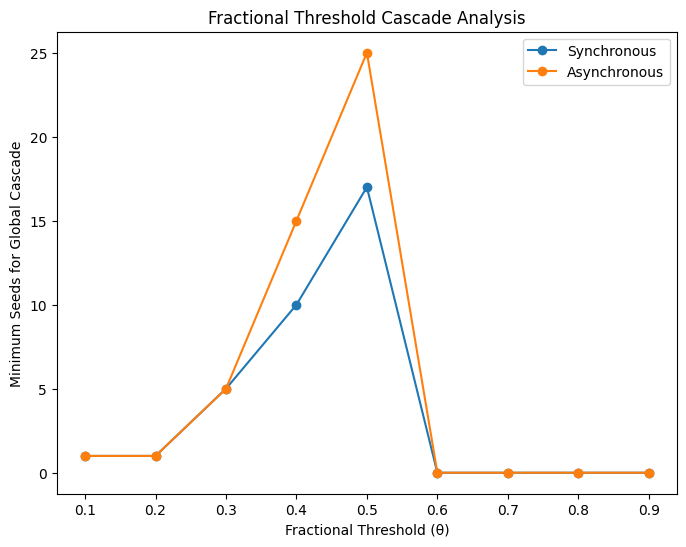

In [ ]:
# ---- Fractional Threshold Models ----

# ---- Synchronous ----
def fractional_sync(G, seeds, theta):

    active = set(seeds)

    while True:
        new_active = set(active)

        for node in G.nodes():
            if node not in active:

                neighbors = list(G.neighbors(node))
                if len(neighbors) == 0:
                    continue

                active_neighbors = sum(1 for n in neighbors if n in active)

                if (active_neighbors / len(neighbors)) >= theta:
                    new_active.add(node)

        if new_active == active:
            break

        active = new_active

    return len(active)


# ---- Asynchronous ----
def fractional_async(G, seeds, theta, max_iter=1000):

    active = set(seeds)
    nodes = list(G.nodes())

    for _ in range(max_iter):

        changed = False
        random.shuffle(nodes)

        for node in nodes:
            if node not in active:

                neighbors = list(G.neighbors(node))
                if len(neighbors) == 0:
                    continue

                active_neighbors = sum(1 for n in neighbors if n in active)

                if (active_neighbors / len(neighbors)) >= theta:
                    active.add(node)
                    changed = True

        if not changed:
            break

    return len(active)


# ---- Find minimum seeds ----
def find_min_seeds_fractional(G, theta, model="sync", max_seeds=30, trials=10):

    N = len(G.nodes())

    for k in range(1, max_seeds + 1):

        success = False

        for _ in range(trials):

            seeds = random.sample(list(G.nodes()), k)

            if model == "sync":
                final_size = fractional_sync(G, seeds, theta)
            else:
                final_size = fractional_async(G, seeds, theta)

            if final_size >= 0.9 * N:
                success = True
                break

        if success:
            return k

    return None


# ---- Run experiment ----

thetas = np.linspace(0.1, 0.9, 9)

results_sync = []
results_async = []

print("\n--- Fractional Threshold Cascade ---")

for theta in thetas:

    min_sync = find_min_seeds_fractional(G_cc, theta, "sync")
    min_async = find_min_seeds_fractional(G_cc, theta, "async")

    results_sync.append(min_sync if min_sync is not None else 0)
    results_async.append(min_async if min_async is not None else 0)

    print(f"\nTheta = {round(theta,2)}")
    print(f"  Sync min seeds: {min_sync}")
    print(f"  Async min seeds: {min_async}")


# ---- Plot ----

plt.figure(figsize=(8,6))

plt.plot(thetas, results_sync, marker='o', label="Synchronous")
plt.plot(thetas, results_async, marker='o', label="Asynchronous")

plt.xlabel("Fractional Threshold (θ)")
plt.ylabel("Minimum Seeds for Global Cascade")
plt.title("Fractional Threshold Cascade Analysis")

plt.legend()
plt.show()